<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Titanic_Classification_Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Classification Assignment
This notebook implements two supervised learning classification models to predict passenger survival on the Titanic dataset.

## 1. Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

## 2. Load the Dataset

In [7]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Quick Inspection

In [8]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe(include='all').T

Shape: (891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 4. Preprocessing Plan
Target variable: `Survived`

Preprocessing decisions:
- Fill missing `Age` values with the median
- Fill missing `Embarked` with the mode
- Create a `CabinKnown` indicator from `Cabin`
- Drop high-cardinality or low-value text identifiers: `PassengerId`, `Name`, `Ticket`, `Cabin`
- One-hot encode categorical columns
- Standardize numeric columns for Logistic Regression


In [9]:
df['CabinKnown'] = df['Cabin'].notna().astype(int)

X = df.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y = df['Survived']

numeric_features = ['Age', 'Fare', 'SibSp', 'Parch', 'CabinKnown']
categorical_features = ['Pclass', 'Sex', 'Embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)


## 5. Exploratory Data Analysis

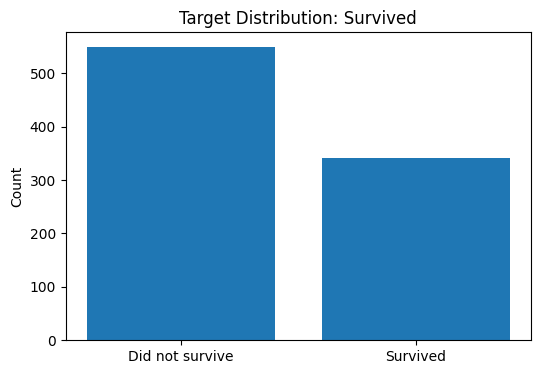

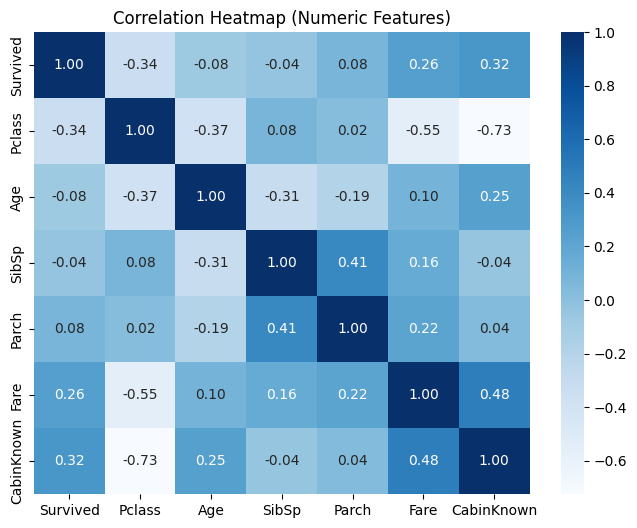

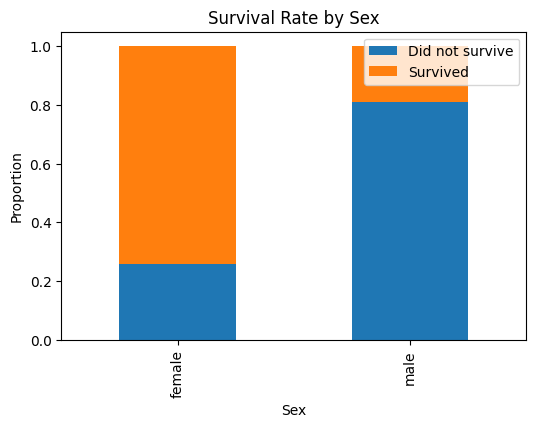

In [10]:
# Survival distribution
plt.figure(figsize=(6,4))
plt.bar(['Did not survive', 'Survived'], df['Survived'].value_counts().sort_index().values)
plt.title('Target Distribution: Survived')
plt.ylabel('Count')
plt.show()

# Correlation heatmap for numeric features
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'CabinKnown']].corr(),
    annot=True, fmt='.2f', cmap='Blues'
)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

# Survival by sex
survival_by_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index')
survival_by_sex.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('Survival Rate by Sex')
plt.ylabel('Proportion')
plt.legend(['Did not survive', 'Survived'])
plt.show()

### EDA Notes
- The classes are moderately imbalanced, with more passengers not surviving than surviving.
- `Sex` and `Pclass` are strong predictors of survival.
- `Fare` has a positive relationship with survival, while `Pclass` has a negative one because larger class numbers indicate lower passenger class.
- Missing values are concentrated mainly in `Age`, `Cabin`, and `Embarked`.


## 6. Model Training and Evaluation

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        min_samples_split=5,
        min_samples_leaf=2
    )
}

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

    trained_models[name] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

results_df = pd.DataFrame(results).sort_values(by='F1-score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.810056,0.786885,0.695652,0.738462,0.837945
1,Random Forest,0.782123,0.767857,0.623188,0.688000,0.838867


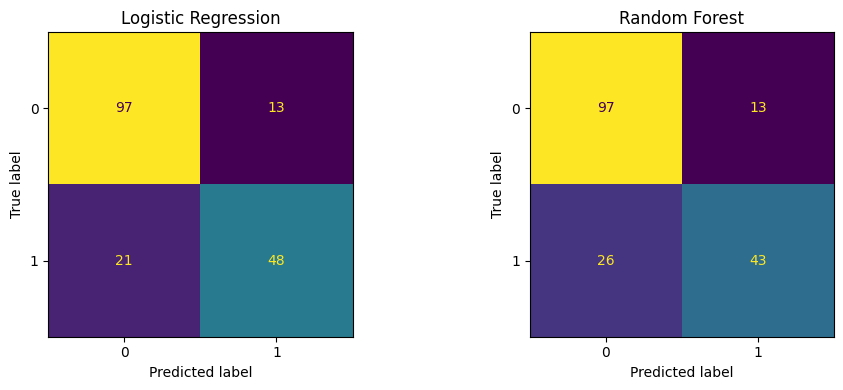

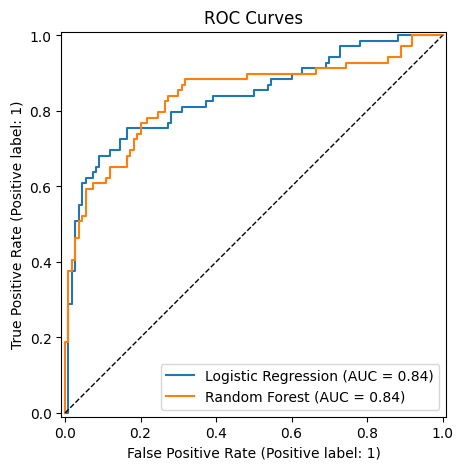

In [12]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10,4))

for ax, (name, data) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(6,5))
for name, data in trained_models.items():
    RocCurveDisplay.from_predictions(y_test, data['y_prob'], name=name, ax=plt.gca())

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.title('ROC Curves')
plt.show()

## 7. Model Interpretation

In [13]:
best_model = results_df.iloc[0]
print("Best model based on F1-score:")
print(best_model)

Best model based on F1-score:
Model        Logistic Regression
Accuracy                0.810056
Precision               0.786885
Recall                  0.695652
F1-score                0.738462
ROC-AUC                 0.837945
Name: 0, dtype: object


Interpretation:
- Logistic Regression performs best overall on this split because it achieves the highest accuracy, precision, recall, and F1-score.
- Random Forest has a nearly identical ROC-AUC, but its recall is lower, meaning it misses more true survivors.
- Since this is a tabular dataset with a relatively small number of features and a mostly linear decision boundary after preprocessing, Logistic Regression is a strong baseline and winner here.


## 8. Example Inference

In [14]:
best_pipeline = trained_models['Logistic Regression']['pipeline']

sample_passenger = pd.DataFrame([{
    'Pclass': 1,
    'Sex': 'female',
    'Age': 29,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 85.0,
    'Embarked': 'C',
    'CabinKnown': 1
}])

survival_probability = best_pipeline.predict_proba(sample_passenger)[0, 1]
predicted_class = best_pipeline.predict(sample_passenger)[0]

print("Predicted survival class:", predicted_class)
print("Predicted survival probability:", round(survival_probability, 4))

Predicted survival class: 1
Predicted survival probability: 0.9637


## 9. Deployment and Monitoring
**Deployment approach**
- Export the trained preprocessing + model pipeline with `joblib`
- Wrap the model in a REST API using FastAPI or Flask
- Deploy to a cloud service such as Render, AWS, Azure, or Google Cloud Run

**Potential production issues**
- Missing or malformed incoming fields
- Data drift, such as changes in fare distribution or class mix
- Class imbalance in future data
- Latency or scaling problems for real-time requests

**Monitoring strategy**
- Log prediction probabilities and input schema validation failures
- Track weekly accuracy/F1 on newly labeled data
- Monitor drift in `Age`, `Fare`, `Pclass`, and `Sex`
- Retrain on an updated dataset when performance degrades


## 10. Save the Best Model

In [15]:
import joblib

joblib.dump(best_pipeline, 'best_titanic_model.joblib')
print("Model saved as best_titanic_model.joblib")

Model saved as best_titanic_model.joblib
